In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\Users\\DELL\\OneDrive\\Sana Projects\\EDA 1 smart route delay\\finaltruck_trip_data_10000_enriched.csv")   # or "trips.xlsx" if Excel


# Ensure datetime columns are parsed
df["Scheduled_Departure"] = pd.to_datetime(df["Scheduled_Departure"])
df["Scheduled_Arrival"] = pd.to_datetime(df["Scheduled_Arrival"])
df["Actual_Departure"] = pd.to_datetime(df["Actual_Departure"])
df["Actual_Arrival"] = pd.to_datetime(df["Actual_Arrival"])

# Recompute key Phase 1 metrics if needed
df["scheduled_duration_min"] = (df["Scheduled_Arrival"] - df["Scheduled_Departure"]).dt.total_seconds() / 60
df["actual_duration_min"] = (df["Actual_Arrival"] - df["Actual_Departure"]).dt.total_seconds() / 60
df["delay_min"] = (df["Actual_Arrival"] - df["Scheduled_Arrival"]).dt.total_seconds() / 60
df["computed_speed"] = df["Distance_km"] / (df["actual_duration_min"] / 60)
df["fuel_efficiency_kmpl"] = df["Distance_km"] / df["Fuel_Consumption_L"]


FUEL_PRICE = 95  

# Weather penalty mapping
WEATHER_PENALTY = {
    "Clear": 1.0,
    "Cloudy": 1.05,
    "Rain": 1.15,
    "Fog": 1.25,
    "Snow": 1.4
}

# Step 1: Base travel time (hrs)
df["travel_time_hr"] = df["Distance_km"] / df["computed_speed"]

# Step 2: Fuel cost (₹)
df["fuel_cost"] = (df["Distance_km"] / df["fuel_efficiency_kmpl"]) * FUEL_PRICE

# Step 3: Weather penalty
df["weather_factor"] = df["Weather_Condition"].map(WEATHER_PENALTY).fillna(1.1)
df["weather_penalty"] = df["travel_time_hr"] * (df["weather_factor"] - 1)

# Step 4: Delay penalty (in hours, weighted)
df["delay_penalty"] = (df["delay_min"] / 60) * 0.5  

# Step 5: Final route score
df["route_score"] = (
    df["travel_time_hr"] + 
    df["weather_penalty"] + 
    df["delay_penalty"] + 
    (df["fuel_cost"] / 1000)
)

# Rank routes (lower is better)
df["route_rank"] = df["route_score"].rank(method="dense")

# -----------------------------
# 🔹 Show Results
# -----------------------------
best_routes = df.sort_values("route_score").head(5)[[
    "Trip_ID", "Start_Location", "End_Location", 
    "travel_time_hr", "fuel_cost", "delay_min", 
    "Weather_Condition", "route_score"
]]

print("🚚 Top 5 Best Routes (Phase 2 Baseline):\n")
print(best_routes.to_string(index=False))   # ✅ Ensures proper visible output

🚚 Top 5 Best Routes (Phase 2 Baseline):

Trip_ID Start_Location End_Location  travel_time_hr  fuel_cost  delay_min Weather_Condition  route_score
  T5540           Pune      Kolkata        1.133333    1156.15        6.0             Storm     2.452817
 T10190      Bangalore         Pune        0.766667    1933.25       -7.0             Storm     2.718250
  T4367        Chennai         Pune        1.316667    1373.70        9.0             Clear     2.765367
  T3693      Ahmedabad      Chennai        1.750000    1053.55      -17.0             Storm     2.836883
  T4791         Jaipur      Chennai        0.783333    2108.05       -3.0             Clear     2.866383


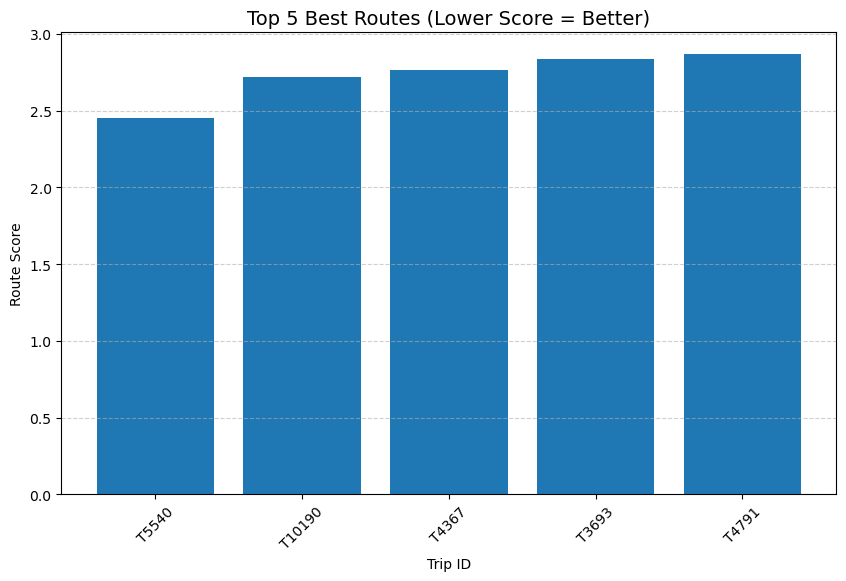

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
plt.bar(best_routes["Trip_ID"].astype(str), best_routes["route_score"])

plt.title("Top 5 Best Routes (Lower Score = Better)", fontsize=14)
plt.xlabel("Trip ID")
plt.ylabel("Route Score")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

🚚 Top 5 Best Routes (Phase 2 Baseline):
     Trip_ID Start_Location End_Location  travel_time_hr  fuel_cost  \
4540   T5540           Pune      Kolkata        1.133333    1156.15   
9190  T10190      Bangalore         Pune        0.766667    1933.25   
3367   T4367        Chennai         Pune        1.316667    1373.70   
2693   T3693      Ahmedabad      Chennai        1.750000    1053.55   
3791   T4791         Jaipur      Chennai        0.783333    2108.05   

      delay_min Weather_Condition  route_score  weather_penalty  delay_penalty  
4540        6.0             Storm     2.452817         0.113333       0.050000  
9190       -7.0             Storm     2.718250         0.076667      -0.058333  
3367        9.0             Clear     2.765367         0.000000       0.075000  
2693      -17.0             Storm     2.836883         0.175000      -0.141667  
3791       -3.0             Clear     2.866383         0.000000      -0.025000  


C:\Users\DELL\AppData\Local\Temp\ipykernel_52248\2587404271.py:80: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


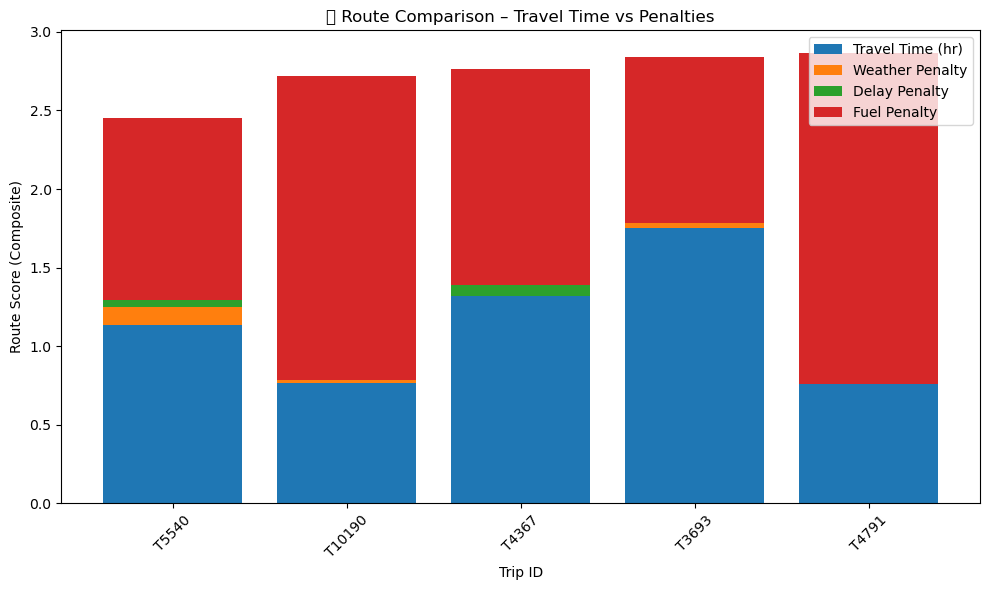

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Example fuel price assumption (₹ per litre)
FUEL_PRICE = 95  

# ✅ Weather penalty factors (relative delay impact)
WEATHER_PENALTY = {
    "Clear": 1.0,
    "Cloudy": 1.05,
    "Rain": 1.15,
    "Fog": 1.25,
    "Snow": 1.4
}


df["travel_time_hr"] = df["Distance_km"] / df["computed_speed"]

# Fuel cost (₹)
df["fuel_cost"] = (df["Distance_km"] / df["fuel_efficiency_kmpl"]) * FUEL_PRICE

# Weather penalty
df["weather_factor"] = df["Weather_Condition"].map(WEATHER_PENALTY).fillna(1.1)
df["weather_penalty"] = df["travel_time_hr"] * (df["weather_factor"] - 1)

# Delay penalty (minutes → hours, half-weighted)
df["delay_penalty"] = (df["delay_min"] / 60) * 0.5  

# Total route score (lower = better)
df["route_score"] = (
    df["travel_time_hr"] +
    df["weather_penalty"] +
    df["delay_penalty"] +
    (df["fuel_cost"] / 1000)
)

# Rank routes
df["route_rank"] = df["route_score"].rank(method="dense")


best_routes = df.sort_values("route_score").head(5)[[
    "Trip_ID", "Start_Location", "End_Location", 
    "travel_time_hr", "fuel_cost", "delay_min", 
    "Weather_Condition", "route_score", 
    "weather_penalty", "delay_penalty"
]]

print("🚚 Top 5 Best Routes (Phase 2 Baseline):")
print(best_routes)

x = np.arange(len(best_routes))  # positions for bars

travel_time = best_routes["travel_time_hr"].values
weather_penalty = best_routes["weather_penalty"].values
delay_penalty = best_routes["delay_penalty"].values
fuel_penalty = (best_routes["fuel_cost"] / 1000).values  # scaled

plt.figure(figsize=(10,6))

# Stacked bars
plt.bar(x, travel_time, label="Travel Time (hr)")
plt.bar(x, weather_penalty, bottom=travel_time, label="Weather Penalty")
plt.bar(x, delay_penalty, bottom=travel_time+weather_penalty, label="Delay Penalty")
plt.bar(x, fuel_penalty, bottom=travel_time+weather_penalty+delay_penalty, label="Fuel Penalty")

# Labels
plt.xticks(x, best_routes["Trip_ID"], rotation=45)
plt.xlabel("Trip ID")
plt.ylabel("Route Score (Composite)")
plt.title("🚚 Route Comparison – Travel Time vs Penalties")
plt.legend()
plt.tight_layout()
plt.show()


🚚 Top 5 Best Routes (Phase 2 Baseline):
     Trip_ID Start_Location End_Location  travel_time_hr  fuel_cost  \
4540   T5540           Pune      Kolkata        1.133333    1156.15   
9190  T10190      Bangalore         Pune        0.766667    1933.25   
3367   T4367        Chennai         Pune        1.316667    1373.70   
2693   T3693      Ahmedabad      Chennai        1.750000    1053.55   
3791   T4791         Jaipur      Chennai        0.783333    2108.05   

      delay_min Weather_Condition  route_score  weather_penalty  delay_penalty  
4540        6.0             Storm     2.452817         0.113333       0.050000  
9190       -7.0             Storm     2.718250         0.076667      -0.058333  
3367        9.0             Clear     2.765367         0.000000       0.075000  
2693      -17.0             Storm     2.836883         0.175000      -0.141667  
3791       -3.0             Clear     2.866383         0.000000      -0.025000  


C:\Users\DELL\AppData\Local\Temp\ipykernel_52248\1021757909.py:66: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


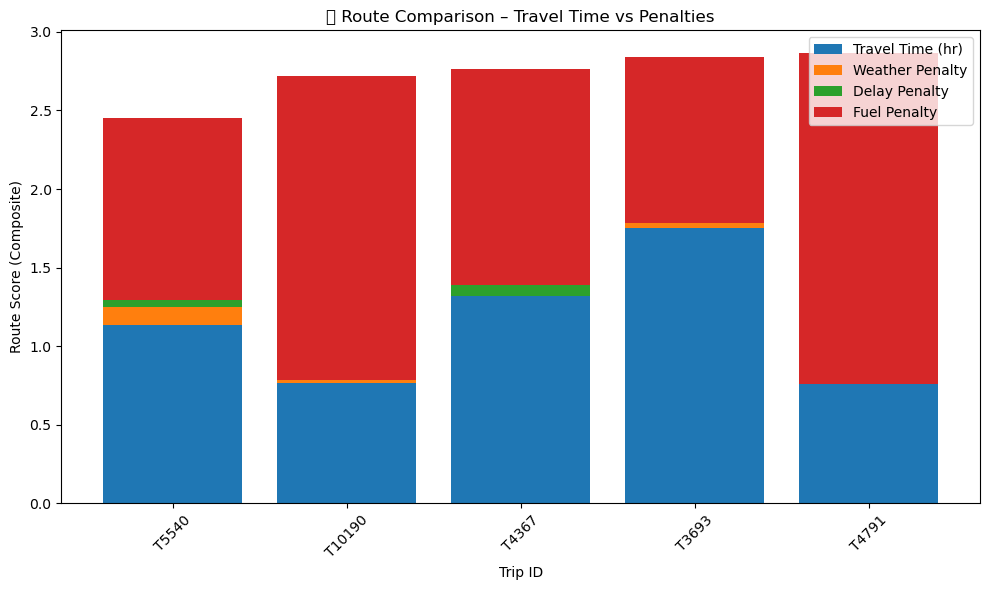


📊 Route Ranking Explanations:
  Trip_ID              From→To                          Why Rank?
0   T5540       Pune → Kolkata  balanced route with low penalties
1  T10190     Bangalore → Pune           higher fuel cost (₹1933)
2   T4367       Chennai → Pune  balanced route with low penalties
3   T3693  Ahmedabad → Chennai  balanced route with low penalties
4   T4791     Jaipur → Chennai           higher fuel cost (₹2108)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# fuel price assumption  per litre)
FUEL_PRICE = 95  

#  Weather penalty factors (relative delay impact)
WEATHER_PENALTY = {
    "Clear": 1.0,
    "Cloudy": 1.05,
    "Rain": 1.15,
    "Fog": 1.25,
    "Snow": 1.4
}
# -------------------------------
df["travel_time_hr"] = df["Distance_km"] / df["computed_speed"]
df["fuel_cost"] = (df["Distance_km"] / df["fuel_efficiency_kmpl"]) * FUEL_PRICE
df["weather_factor"] = df["Weather_Condition"].map(WEATHER_PENALTY).fillna(1.1)
df["weather_penalty"] = df["travel_time_hr"] * (df["weather_factor"] - 1)
df["delay_penalty"] = (df["delay_min"] / 60) * 0.5  
df["route_score"] = (
    df["travel_time_hr"] +
    df["weather_penalty"] +
    df["delay_penalty"] +
    (df["fuel_cost"] / 1000)
)
df["route_rank"] = df["route_score"].rank(method="dense")


best_routes = df.sort_values("route_score").head(5)[[
    "Trip_ID", "Start_Location", "End_Location", 
    "travel_time_hr", "fuel_cost", "delay_min", 
    "Weather_Condition", "route_score", 
    "weather_penalty", "delay_penalty"
]]

print("🚚 Top 5 Best Routes (Phase 2 Baseline):")
print(best_routes)


x = np.arange(len(best_routes))  # positions for bars

travel_time = best_routes["travel_time_hr"].values
weather_penalty = best_routes["weather_penalty"].values
delay_penalty = best_routes["delay_penalty"].values
fuel_penalty = (best_routes["fuel_cost"] / 1000).values  # scaled

plt.figure(figsize=(10,6))
plt.bar(x, travel_time, label="Travel Time (hr)")
plt.bar(x, weather_penalty, bottom=travel_time, label="Weather Penalty")
plt.bar(x, delay_penalty, bottom=travel_time+weather_penalty, label="Delay Penalty")
plt.bar(x, fuel_penalty, bottom=travel_time+weather_penalty+delay_penalty, label="Fuel Penalty")
plt.xticks(x, best_routes["Trip_ID"], rotation=45)
plt.xlabel("Trip ID")
plt.ylabel("Route Score (Composite)")
plt.title("🚚 Route Comparison – Travel Time vs Penalties")
plt.legend()
plt.tight_layout()
plt.show()

#  Explanatory Summary

summary = []
for _, row in best_routes.iterrows():
    reason = []
    if row["weather_penalty"] > 0.5:
        reason.append(f"weather impact ({row['Weather_Condition']})")
    if row["delay_penalty"] > 0.5:
        reason.append(f"delay penalty ({row['delay_min']} min)")
    if row["fuel_cost"] > best_routes["fuel_cost"].median():
        reason.append(f"higher fuel cost (₹{row['fuel_cost']:.0f})")
    if not reason:
        reason.append("balanced route with low penalties")
    
    summary.append({
        "Trip_ID": row["Trip_ID"],
        "From→To": f"{row['Start_Location']} → {row['End_Location']}",
        "Why Rank?": ", ".join(reason)
    })

summary_df = pd.DataFrame(summary)
print("\n📊 Route Ranking Explanations:")
print(summary_df)


🚚 Top 5 Best Routes (Phase 2 Baseline):
     Trip_ID Start_Location End_Location  travel_time_hr  fuel_cost  \
4540   T5540           Pune      Kolkata        1.133333    1156.15   
9190  T10190      Bangalore         Pune        0.766667    1933.25   
3367   T4367        Chennai         Pune        1.316667    1373.70   
2693   T3693      Ahmedabad      Chennai        1.750000    1053.55   
3791   T4791         Jaipur      Chennai        0.783333    2108.05   

      delay_min Weather_Condition  route_score  weather_penalty  delay_penalty  
4540        6.0             Storm     2.452817         0.113333       0.050000  
9190       -7.0             Storm     2.718250         0.076667      -0.058333  
3367        9.0             Clear     2.765367         0.000000       0.075000  
2693      -17.0             Storm     2.836883         0.175000      -0.141667  
3791       -3.0             Clear     2.866383         0.000000      -0.025000  


C:\Users\DELL\AppData\Local\Temp\ipykernel_52248\3281769779.py:66: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  plt.tight_layout()
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128666 (\N{DELIVERY TRUCK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


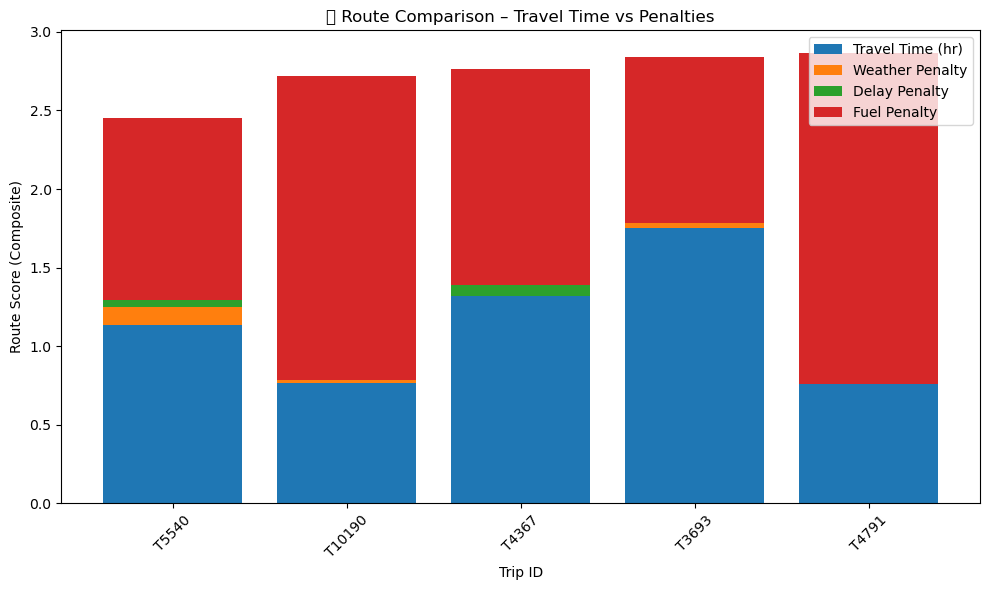


📊 Route Ranking Explanations:
  Trip_ID              From→To                          Why Rank?
0   T5540       Pune → Kolkata  balanced route with low penalties
1  T10190     Bangalore → Pune           higher fuel cost (₹1933)
2   T4367       Chennai → Pune  balanced route with low penalties
3   T3693  Ahmedabad → Chennai  balanced route with low penalties
4   T4791     Jaipur → Chennai           higher fuel cost (₹2108)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Example fuel price assumption (₹ per litre)
FUEL_PRICE = 95  

# ✅ Weather penalty factors (relative delay impact)
WEATHER_PENALTY = {
    "Clear": 1.0,
    "Cloudy": 1.05,
    "Rain": 1.15,
    "Fog": 1.25,
    "Snow": 1.4
}


# Compute base metrics
df["travel_time_hr"] = df["Distance_km"] / df["computed_speed"]
df["fuel_cost"] = (df["Distance_km"] / df["fuel_efficiency_kmpl"]) * FUEL_PRICE
df["weather_factor"] = df["Weather_Condition"].map(WEATHER_PENALTY).fillna(1.1)
df["weather_penalty"] = df["travel_time_hr"] * (df["weather_factor"] - 1)
df["delay_penalty"] = (df["delay_min"] / 60) * 0.5  
df["route_score"] = (
    df["travel_time_hr"] +
    df["weather_penalty"] +
    df["delay_penalty"] +
    (df["fuel_cost"] / 1000)
)
df["route_rank"] = df["route_score"].rank(method="dense")

#  top 5 best routes
best_routes = df.sort_values("route_score").head(5)[[
    "Trip_ID", "Start_Location", "End_Location", 
    "travel_time_hr", "fuel_cost", "delay_min", 
    "Weather_Condition", "route_score", 
    "weather_penalty", "delay_penalty"
]]

print("🚚 Top 5 Best Routes (Phase 2 Baseline):")
print(best_routes)

# Visualization
x = np.arange(len(best_routes))  # positions for bars

travel_time = best_routes["travel_time_hr"].values
weather_penalty = best_routes["weather_penalty"].values
delay_penalty = best_routes["delay_penalty"].values
fuel_penalty = (best_routes["fuel_cost"] / 1000).values  # scaled

plt.figure(figsize=(10,6))
plt.bar(x, travel_time, label="Travel Time (hr)")
plt.bar(x, weather_penalty, bottom=travel_time, label="Weather Penalty")
plt.bar(x, delay_penalty, bottom=travel_time+weather_penalty, label="Delay Penalty")
plt.bar(x, fuel_penalty, bottom=travel_time+weather_penalty+delay_penalty, label="Fuel Penalty")
plt.xticks(x, best_routes["Trip_ID"], rotation=45)
plt.xlabel("Trip ID")
plt.ylabel("Route Score (Composite)")
plt.title("🚚 Route Comparison – Travel Time vs Penalties")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------
# 🟢 Step 4: Explanatory Summary
# -----------------------------------
summary = []
for _, row in best_routes.iterrows():
    reason = []
    if row["weather_penalty"] > 0.5:
        reason.append(f"weather impact ({row['Weather_Condition']})")
    if row["delay_penalty"] > 0.5:
        reason.append(f"delay penalty ({row['delay_min']} min)")
    if row["fuel_cost"] > best_routes["fuel_cost"].median():
        reason.append(f"higher fuel cost (₹{row['fuel_cost']:.0f})")
    if not reason:
        reason.append("balanced route with low penalties")
    
    summary.append({
        "Trip_ID": row["Trip_ID"],
        "From→To": f"{row['Start_Location']} → {row['End_Location']}",
        "Why Rank?": ", ".join(reason)
    })

summary_df = pd.DataFrame(summary)
print("\n📊 Route Ranking Explanations:")
print(summary_df)